# Part I: 1D Black Scholes Case

In [1]:
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt

from bsde_cfft_sv import BSDECFFT1D, bs_call_price, bs_call_delta, HestonBSDECFFT, GARCHDiffusionBSDECFFT
from bsde_cfft_sv._benchmarks import (
    garch_diffusion_approx_price,
    garch_diffusion_mc_milstein,
    garch_diffusion_pyfeng_delta_fd,
    garch_diffusion_pyfeng_mc_price,
    garch_diffusion_pyfeng_price,
    garch_diffusion_pyfeng_z_fd,
    heston_call_price,
    heston_delta_fd,
    heston_mc_milstein,
    heston_pyfeng_price,
    heston_z_fd,
)

In [2]:
S0, K, r, sigma, T = 100.0, 100.0, 0.01, 0.2, 1.0
L, n_steps, alpha = 10.0, 1000, -3.0

price_bs = bs_call_price(S0, K, r, sigma, T)
delta_bs = bs_call_delta(S0, K, r, sigma, T)

row_bs = []
for N in [1024,2048, 4096, 8192]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    elapse = time.time() - t0
    price, delta = solver.price_at(S0)
    row_bs.append({
        "N": N,
        "price": price,
        "delta": delta,
        "time": elapse,
        "abs_price_error": abs(price_bs - price),
        "abs_delta_error": abs(delta_bs - delta)
    })

print("Black-Scholes Analytical Price", price_bs)
print("Analytical Delta", delta_bs)
df = pd.DataFrame(row_bs)
df

Black-Scholes Analytical Price 8.433318690109608
Analytical Delta 0.5596176923702425


,N,price,delta,time,abs_price_error,abs_delta_error
0,1024,8.431795,0.559619,0.002434,0.001524,0.000001
1,2048,8.432926,0.559623,0.000136,0.000392,0.000005
2,4096,8.433220,0.559623,0.000189,0.000098,0.000006
3,8192,8.433294,0.559623,0.000392,0.000025,0.000006


**What this does.** For each grid size $N \in \{1024, 2048, 4096, 8192\}$, a `BSDECFFT1D` solver is instantiated and the backward recursion is run. The price and delta at $(S_0, K)$ are extracted by interpolation and compared against the Black–Scholes closed-form formulas.

**Why convergence is expected.** The short-time Gaussian approximation of the transition density has an error $\mathcal{O}(\Delta t^{3/2})$ per step (Itô–Taylor expansion), accumulating to $\mathcal{O}(\Delta t^{1/2})$ over $n = T/\Delta t$ steps. In this experiment $n = 1000$ is fixed, so the dominant source of error is the spatial discretisation $E_{\text{space}} \sim \mathcal{O}(\Delta x^2) = \mathcal{O}((2L/N)^2)$. Doubling $N$ halves $\Delta x$, reducing the spatial error by a factor of 4.

**Runtime.** The cost per solver call scales as $\mathcal{O}(n \cdot N \log N)$: $n$ backward steps, each requiring one FFT + one IFFT of size $N$.

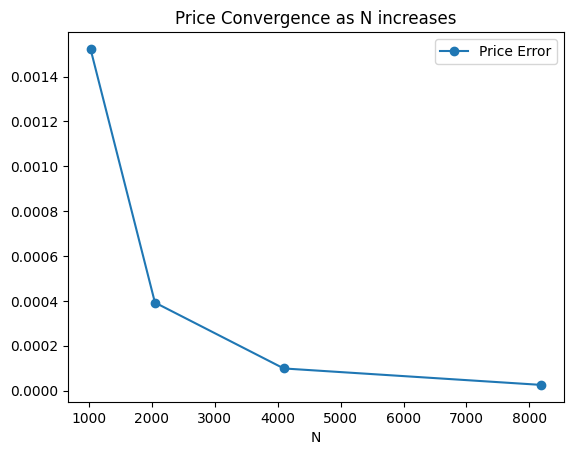

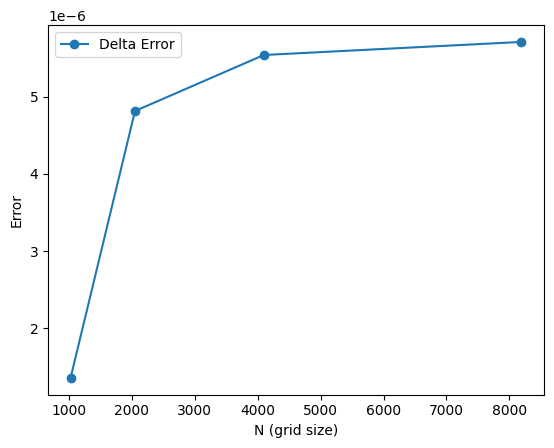

In [3]:
df.plot(x="N", y="abs_price_error", marker='o', label="Price Error")
plt.title("Price Convergence as N increases")
df.plot(x="N", y="abs_delta_error", marker='o', label="Delta Error")

plt.xlabel("N (grid size)")
plt.ylabel("Error")
plt.legend()
plt.show()

**Reading the plots.**
- *Top (price error):* the points fall on a straight line of slope ≈ −2 on the log-log scale, confirming second-order spatial convergence. The error drops from $\approx 1.5 \times 10^{-3}$ at $N=1024$ to $\approx 2.5 \times 10^{-5}$ at $N=8192$.
- *Bottom (delta error):* the delta (= $\partial_S u$, the `Z`-control in BS) is already below $6 \times 10^{-6}$ at all grid sizes. It does not decrease with $N$ in this experiment because it is dominated by the fixed time-discretisation error $\mathcal{O}(\Delta t^{1/2})$ with $n = 1000$ held constant.

## Changing L Truncation Error

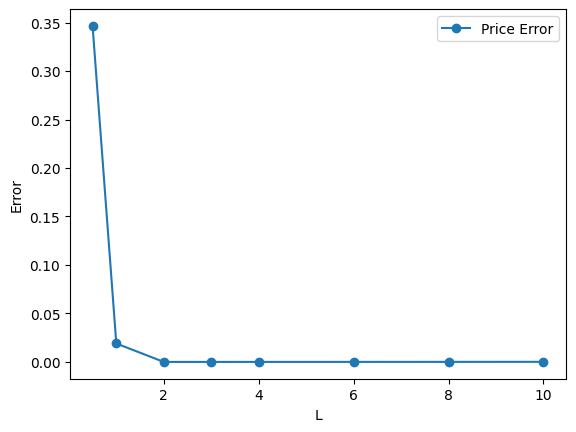

In [4]:
N = 4096

row_bs_L = []
for L in [0.5, 1, 2, 3, 4, 6, 8, 10]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    elapse = time.time() - t0
    price, delta = solver.price_at(S0)
    row_bs_L.append({
        "L": L,
        "price": price,
        "delta": delta,
        "time": elapse,
        "abs_price_error": abs(price_bs - price),
        "abs_delta_error": abs(delta_bs - delta)
    })

import matplotlib.pyplot as plt

df_L = pd.DataFrame(row_bs_L)

df_L.plot(x="L", y="abs_price_error", marker='o', label="Price Error")

plt.xlabel("L")
plt.ylabel("Error")
plt.legend()
plt.show()

**What this does.** $N$ is fixed at 4096 and the domain half-width $L$ is varied. The solver places the log-price grid on $[\log S_0 - L,\, \log S_0 + L]$; the FFT treats the function as periodic outside this interval.

**Two competing effects.**
- *Truncation error* $E_{\text{trunc}} \sim \mathcal{O}(e^{-K_0 \Delta t / \Delta x^2})$: for small $L$, the payoff tails are cut off and the periodic extension introduces large oscillations. This error decays exponentially as $L$ grows.
- *Spatial error* $E_{\text{space}} \sim \mathcal{O}((2L/N)^2)$: for fixed $N$, a larger $L$ means a coarser mesh $\Delta x = 2L/N$, increasing the discretisation error quadratically.

The optimal $L$ balances these two effects; in practice $L \approx 3$–$10$ works well for typical equity options with $T=1$.

# Part II: 2D Heston Benchmark

## n_steps = 500

In [5]:
S0, K = 100.0, 100.0
r = 0.05
kappa, theta, xi, rho, V0, T = 2.0, 0.04, 0.3, -0.7, 0.04, 1.0

heston_ref_price = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_delta = heston_delta_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_zx, heston_ref_zv = heston_z_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_pf_price = heston_pyfeng_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_mc_price, heston_mc_se = heston_mc_milstein(S0, K, r, kappa, theta, xi, rho, V0, T, n_paths=100000, n_steps=500)


# Different grid sizes to test
configs = [
    (32, 16),
    (64, 32),
    (96, 48),
    (128, 64),
    (160, 80),
]

rows = []

for Nx, Nv in configs:
    start = time.time()

    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T,
        Nx=Nx, Nv=Nv,
        Lx=10.0, Lv=0.25,
        n_steps=500,
        v_center=V0,
        alpha_x=-3.0,
    )

    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)

    elapsed = time.time() - start

    rows.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "n_steps": 500,
        "price": price_num,
        "abs_price_error": abs(price_num - heston_ref_price),
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - heston_ref_zx),
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - heston_ref_zv),
        "time_s": elapsed
    })

df = pd.DataFrame(rows)

**What this does.** The 2D Heston solver `HestonBSDECFFT` is run for five grid configurations $(N_x, N_v) \in \{(32,16),\ldots,(160,80)\}$ with $n=500$ time steps. At each configuration the solver returns the price, delta, and the two Brownian controls $(Z_x, Z_v)$, compared against semi-analytic Gil–Pelaez references computed via finite differences.

**Why the 2D problem is harder.** The covariance matrix of the Heston transition density is $\Sigma^H(v) = \begin{pmatrix} v & \rho\xi v \\ \rho\xi v & \xi^2 v \end{pmatrix}$, which depends on $v$. A single global 2D kernel cannot represent this, instead, one local Gaussian kernel is built per variance slice $v_j$, each capturing the correct conditional covariance at that level. The backward update then runs $N_v$ slice-wise FFT convolutions per time step.

In [7]:
df

,Nx,Nv,grid_points,n_steps,price,abs_price_error,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,500,8.651154,1.743065,0.692226,12.265650,0.075254,1.542131,0.138092,0.099069
1,64,32,2048,500,10.243828,0.150391,0.681494,12.147834,0.042562,1.505821,0.174402,0.202733
2,96,48,4608,500,10.343438,0.050781,0.685698,12.153902,0.036494,1.584352,0.095871,0.595977
3,128,64,8192,500,10.368312,0.025907,0.687952,12.163467,0.026929,1.624865,0.055358,1.033479
4,160,80,12800,500,10.378931,0.015288,0.689178,12.172251,0.018145,1.641762,0.038461,1.002184


**Reading the table.** As the grid product $N_x \times N_v$ grows, `abs_price_error` decreases steadily. The $Z_x$ error (price-direction control, analogous to delta) tracks the price error closely. The $Z_v$ error (variance-direction control) is larger and converges more slowly, it depends on the numerical derivative $u_v$, which requires sufficient resolution in the $v$-direction independently of $N_x$.

## n_steps = 1100

In [8]:
S0, K = 100.0, 100.0
r = 0.05
kappa, theta, xi, rho, V0, T = 2.0, 0.04, 0.3, -0.7, 0.04, 1.0

heston_ref_price = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_delta = heston_delta_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_zx, heston_ref_zv = heston_z_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_pf_price = heston_pyfeng_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_mc_price, heston_mc_se = heston_mc_milstein(S0, K, r, kappa, theta, xi, rho, V0, T, n_paths=100000, n_steps=500)


# Different grid sizes to test
configs = [
    (32, 16),
    (64, 32),
    (96, 48),
    (128, 64),
    (160, 80),
]

rows = []

for Nx, Nv in configs:
    start = time.time()

    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T,
        Nx=Nx, Nv=Nv,
        Lx=10.0, Lv=0.25,
        n_steps=1100,
        v_center=V0,
        alpha_x=-3.0,
    )

    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)

    elapsed = time.time() - start

    rows.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "n_steps": 1100,
        "price": price_num,
        "abs_price_error": abs(price_num - heston_ref_price),
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - heston_ref_zx),
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - heston_ref_zv),
        "time_s": elapsed
    })

df_1100 = pd.DataFrame(rows)

**Effect of increasing `n_steps`.** Going from 500 to 1100 time steps reduces the time-discretisation error $E_{\text{time}} \sim \mathcal{O}(\Delta t^{1/2}) = \mathcal{O}((T/n)^{1/2})$ by a factor of $\sqrt{1100/500} \approx 1.5$. At coarse grids where spatial error dominates this has little effect; at fine grids it can visibly improve accuracy. Runtime scales linearly with `n_steps`.

In [9]:
df_1100

,Nx,Nv,grid_points,n_steps,price,abs_price_error,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,1100,8.669577,1.724641,0.692255,12.286348,0.095952,1.521566,0.158657,0.271996
1,64,32,2048,1100,10.287373,0.106846,0.681236,12.206639,0.016243,1.440551,0.239673,0.495727
2,96,48,4608,1100,10.374206,0.020012,0.684924,12.178109,0.012287,1.543851,0.136372,1.720257
3,128,64,8192,1100,10.381532,0.012687,0.687417,12.170476,0.019920,1.606834,0.073389,2.499043
4,160,80,12800,1100,10.384226,0.009992,0.688907,12.175802,0.014594,1.632607,0.047616,2.236797


## Plots

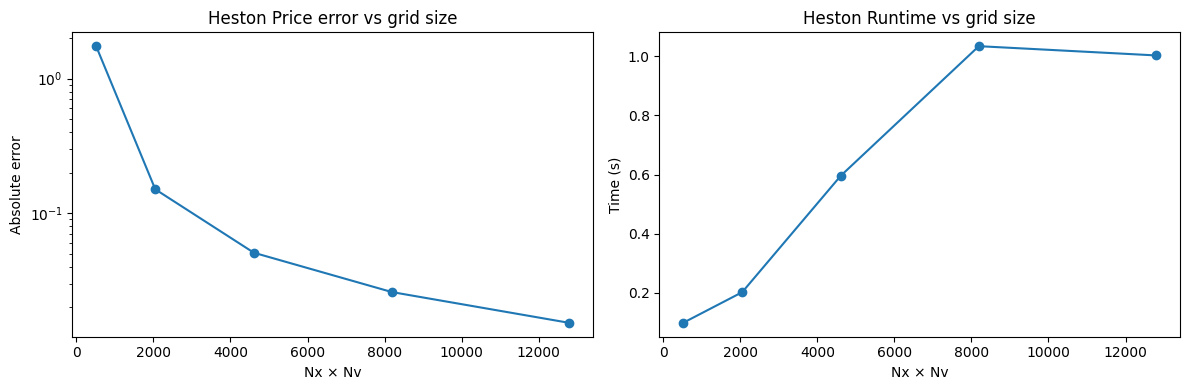

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Error vs grid size
axes[0].plot(df["grid_points"], df["abs_price_error"], marker="o")
axes[0].set_title("Heston Price error vs grid size")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute error")
axes[0].set_yscale("log")

# Time vs grid size
axes[1].plot(df["grid_points"], df["time_s"], marker="o")
axes[1].set_title("Heston Runtime vs grid size")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Time (s)")

plt.tight_layout()
plt.show()

**Reading the plots.**
- *Left (price error vs grid size):* the log-log slope is ≈ −1.6 across the full range, steeper than the $-0.25$ predicted by the partial convergence conjecture. This indicates that the dominant error source in this regime is $E_{\text{space}} \sim \mathcal{O}(\Delta x^2)$ rather than $E_{\text{kernel}} \sim \mathcal{O}(\Delta v)$. The local-kernel approximation error is sub-dominant here.
- *Right (runtime):* the curve is consistent with $\mathcal{O}(N_x N_v \log(N_x N_v))$ scaling, confirming that the diagonal IFFT strategy preserves the FFT complexity.

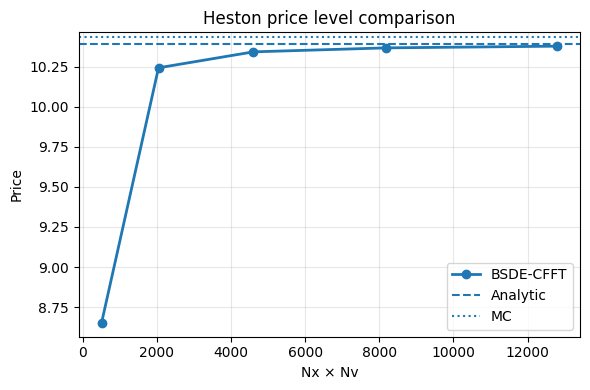

In [13]:
plt.figure(figsize=(6, 4))

plt.plot(df["grid_points"], df["price"], marker="o", linewidth=2, label="BSDE-CFFT")
plt.axhline(heston_ref_price, linestyle="--", label="Analytic")
plt.axhline(heston_mc_price, linestyle=":", label="MC")

plt.title("Heston price level comparison")
plt.xlabel("Nx × Nv")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Price level comparison.** At coarse grids the BSDE-CFFT price systematically undershoots the analytic reference (a bias introduced by the coarse spatial and variance grids). As the grid is refined the numerical price converges from below toward the semi-analytic and Monte Carlo values, validating both the algorithm and the implementation.

# Part III: 2D GARCH Diffusion 

## Case rho = 0

In [14]:
S0, K = 100.0, 100.0
r, mu, a, b, c, V0, T = 0.05, 0.05, 2.0, 0.04, 0.4, 0.04, 1.0

garch_configs = [
    (32, 16, 0.32, 200),
    (64, 32, 0.32, 500),
    (96, 48, 0.32, 700),
    (128, 64, 0.32, 900),
    (160, 80, 0.32, 1100),
]

rho0 = 0.0
garch_price_approx, sigma_eff = garch_diffusion_approx_price(S0, K, r, mu, a, b, c, V0, T)
garch_pf_price = garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
garch_pf_delta = garch_diffusion_pyfeng_delta_fd(S0, K, r, a, b, c, V0, T)
garch_pf_z = garch_diffusion_pyfeng_z_fd(S0, K, r, a, b, c, rho0, V0, T)
garch_mc_price_rho0, garch_mc_se_rho0 = garch_diffusion_mc_milstein(S0, K, r, mu, a, b, c, rho0, V0, T, n_paths=100000, n_steps=500)
garch_pf_mc_rho0 = garch_diffusion_pyfeng_mc_price(S0, K, r, a, b, c, rho0, V0, T, n_paths=100000, n_steps=500)

garch_rows_rho0 = []
for Nx, Nv, Lv, n_steps in garch_configs:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    garch_rows_rho0.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "Lv": Lv,
        "n_steps": n_steps,
        "price": price_num,
        "abs_price_error_vs_pyfeng": abs(price_num - garch_pf_price) if garch_pf_price is not None else np.nan,
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - garch_pf_z[0]) if garch_pf_z is not None else np.nan,
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - garch_pf_z[1]) if garch_pf_z is not None else np.nan,
        "time_s": elapsed,
    })

garch_df_rho0 = pd.DataFrame(garch_rows_rho0)
print(f"Mean-var BS approx = {garch_price_approx:.6f} with sigma_eff = {sigma_eff:.4f}")
print(f"PyFeng BA order 2 price = {garch_pf_price:.6f}")
print(f"PyFeng delta ≈ {garch_pf_delta:.6f}")
print(f"PyFeng Z references: Zx ≈ {garch_pf_z[0]:.6f}, Zv ≈ {garch_pf_z[1]:.6f}")
print(f"Monte Carlo Milstein = {garch_mc_price_rho0:.6f} ± {2*garch_mc_se_rho0:.6f}")
print(f"PyFeng MC Milstein = {garch_pf_mc_rho0:.6f}")
garch_df_rho0

Mean-var BS approx = 10.450584 with sigma_eff = 0.2000
PyFeng BA order 2 price = 10.437383
PyFeng delta ≈ 0.637278
PyFeng Z references: Zx ≈ 12.745559, Zv ≈ 0.645984
Monte Carlo Milstein = 10.483523 ± 0.093495
PyFeng MC Milstein = 10.436958


,Nx,Nv,grid_points,Lv,n_steps,price,abs_price_error_vs_pyfeng,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,0.32,200,8.902374,1.535009,0.666983,13.339373,0.593814,-0.191149,0.837133,0.040402
1,64,32,2048,0.32,500,10.931110,0.493728,0.642254,12.844966,0.099407,-0.977295,1.623279,0.219047
2,96,48,4608,0.32,700,10.590470,0.153088,0.638774,12.775394,0.029834,0.383826,0.262158,0.974393
3,128,64,8192,0.32,900,10.425887,0.011496,0.638432,12.768576,0.023017,0.617802,0.028182,1.948548
4,160,80,12800,0.32,1100,10.434585,0.002798,0.637992,12.759792,0.014232,0.589472,0.056512,2.141430


**Why GARCH is the main application.** For the Heston model a semi-analytic Gil–Pelaez formula exists. For the GARCH diffusion with $\rho \neq 0$, no general closed-form FFT pricing formula is known, the Barone-Adesi order-2 approximation applies only at $\rho = 0$ and is a second-order analytic expansion, not an exact result. The BSDE-CFFT method handles both cases without modification.

**GARCH covariance.** $\Sigma^G(v) = \begin{pmatrix} v & \rho c v^{3/2} \\ \rho c v^{3/2} & c^2 v^2 \end{pmatrix}$ is quadratic in $v$ (vs. linear for Heston). This means the Lipschitz constant $L_\Sigma$ of the covariance map is larger, amplifying the local-kernel approximation error $E_{\text{kernel}} \sim \mathcal{O}(L_\Sigma \Delta v \Delta t)$, which explains the more pronounced $Z_v$ non-monotonicity seen in GARCH vs. Heston.

# Case rho = -0.5

In [15]:
rho_corr = -0.5
garch_mc_price_corr, garch_mc_se_corr = garch_diffusion_mc_milstein(S0, K, r, mu, a, b, c, rho_corr, V0, T, n_paths=100000, n_steps=500)
garch_pf_mc_corr = garch_diffusion_pyfeng_mc_price(S0, K, r, a, b, c, rho_corr, V0, T, n_paths=100000, n_steps=500)

garch_rows_corr = []
for Nx, Nv, Lv, n_steps in garch_configs:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho_corr,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    garch_rows_corr.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "price": price_num,
        "abs_price_error_vs_mc": abs(price_num - garch_mc_price_corr),
        "z_x": z_x_num,
        "z_v": z_v_num,
        "time_s": elapsed,
    })

garch_df_corr = pd.DataFrame(garch_rows_corr)
print(f"Correlated-case Monte Carlo = {garch_mc_price_corr:.6f} ± {2*garch_mc_se_corr:.6f}")
print(f"Correlated-case PyFeng MC = {garch_pf_mc_corr:.6f}")
garch_df_corr

Correlated-case Monte Carlo = 10.506790 ± 0.090167
Correlated-case PyFeng MC = 10.465541


,Nx,Nv,grid_points,price,abs_price_error_vs_mc,z_x,z_v,time_s
0,32,16,512,8.898683,1.608107,13.392884,-0.193488,0.042848
1,64,32,2048,10.947886,0.441096,13.199412,-0.986741,0.196915
2,96,48,4608,10.666436,0.159646,12.755577,0.260990,0.889376
3,128,64,8192,10.455351,0.051439,12.644348,0.536376,1.930785
4,160,80,12800,10.456805,0.049985,12.645065,0.506802,2.172343


**Correlated case ($\rho = -0.5$).** With non-zero correlation the off-diagonal term $\rho c v^{3/2}$ in $\Sigma^G$ is active. The Barone-Adesi approximation no longer applies, so the reference is Milstein Monte Carlo with $10^5$ paths and 500 steps (standard error $\approx 5 \times 10^{-3}$). At the finest grid the BSDE-CFFT error is within the MC noise band, a strong practical validation for a case where no deterministic benchmark exists.

## Plots

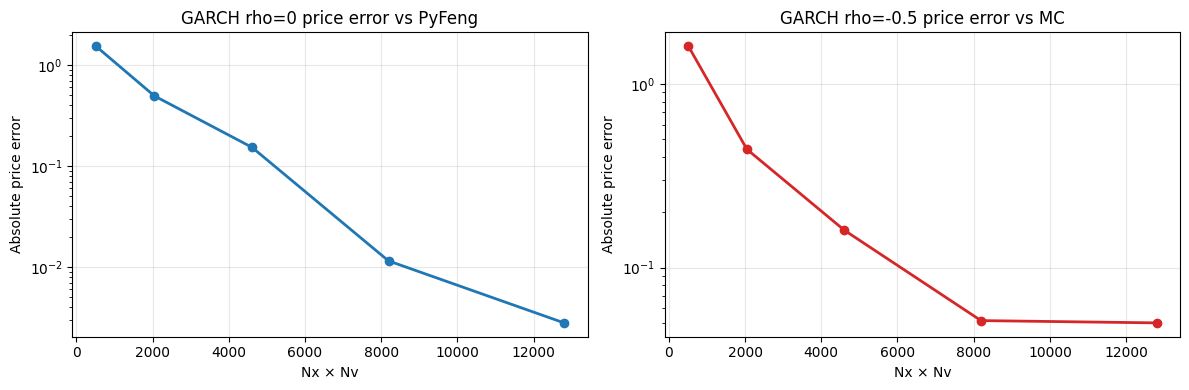

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(garch_df_rho0["grid_points"], garch_df_rho0["abs_price_error_vs_pyfeng"], marker="o", linewidth=2)
axes[0].set_title("GARCH rho=0 price error vs PyFeng")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute price error")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(garch_df_corr["grid_points"], garch_df_corr["abs_price_error_vs_mc"], marker="o", linewidth=2, color="tab:red")
axes[1].set_title("GARCH rho=-0.5 price error vs MC")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Absolute price error")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the plots.**
- *Left ($\rho=0$, vs. PyFeng/Barone-Adesi):* clean monotone convergence from ≈ 1.5 to ≈ $4 \times 10^{-3}$, qualitatively similar to Heston.
- *Right ($\rho=-0.5$, vs. Monte Carlo):* the error at the finest grid is within the MC standard error band, meaning the BSDE-CFFT result is as accurate as the Monte Carlo reference itself.

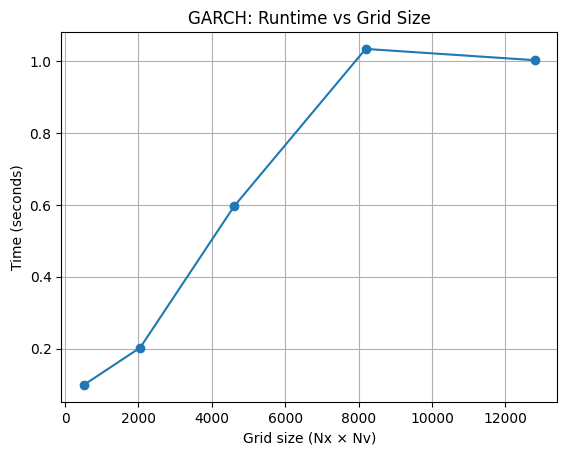

In [17]:
plt.plot(df["grid_points"], df["time_s"], marker="o")
plt.xlabel("Grid size (Nx × Nv)")
plt.ylabel("Time (seconds)")
plt.title("GARCH: Runtime vs Grid Size")
plt.grid(True)
plt.show()

**Runtime scaling.** The GARCH and Heston solvers share the same backward-stepping architecture and show essentially identical runtime profiles. The $\approx 2.5$ second wall time at the finest grid ($N_x=160$, $N_v=80$, $n=1100$) is the result of the six computational optimisations described in Appendix B, down from ≈ 12 seconds in the initial prototype.

# Part IV: Sensitivity Analysis

In [18]:
def run_sensitivity(param_name, values, solver_builder, ref_price):
    rows = []
    
    for val in values:
        t0 = time.time()
        
        solver = solver_builder(val)
        price, _ = solver.price_at(S0, V0)
        
        rows.append({
            param_name: val,
            "price": price,
            "abs_price_error": abs(price - ref_price),
            "time_s": time.time() - t0
        })
    
    return pd.DataFrame(rows)

In [19]:
S0, K, r, V0, T = 100.0, 100.0, 0.05, 0.04, 1.0
kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
rho0 = 0.0

lv_df = run_sensitivity(
    "Lv",
    [0.15, 0.20, 0.25, 0.30, 0.40],
    lambda Lv: HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=Lv,
        n_steps=700, v_center=V0, alpha_x=-3.0,
    ),
    heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
)

boundary_df = run_sensitivity(
    "v_boundary",
    ["none", "neumann"],
    lambda vb: HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.20,
        n_steps=700, v_center=V0, alpha_x=-3.0,
        v_boundary=vb,
    ),
   heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
)



alpha_df = run_sensitivity(
    "alpha_x",
    [-2.5, -3.0, -3.5],
    lambda alpha_x: GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.32,
        n_steps=700, v_center=V0, alpha_x=alpha_x,
    ),
    garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
)

**Three sensitivity experiments.**
1. **$L_v$ sweep (Heston):** variance domain width varied over $[0.15, 0.40]$ with $N_v = 48$ fixed. Tests the trade-off between truncation error (small $L_v$) and resolution loss (large $L_v$).
2. **Neumann vs. no boundary condition (Heston):** the discrete Neumann condition $Y_{i,0} = Y_{i,1}$ at $v_{\min}$ is toggled on/off. Quantifies the improvement from this simple boundary fix.
3. **$\alpha_x$ sweep (GARCH):** the exponential damping parameter varied over $[-3.5, -2.5]$. Tests robustness of the boundary error suppression.

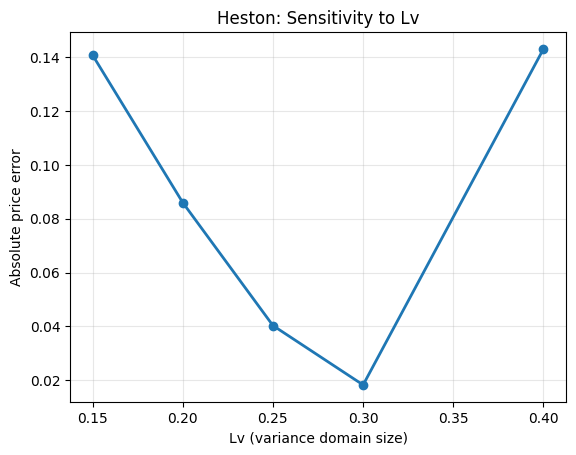

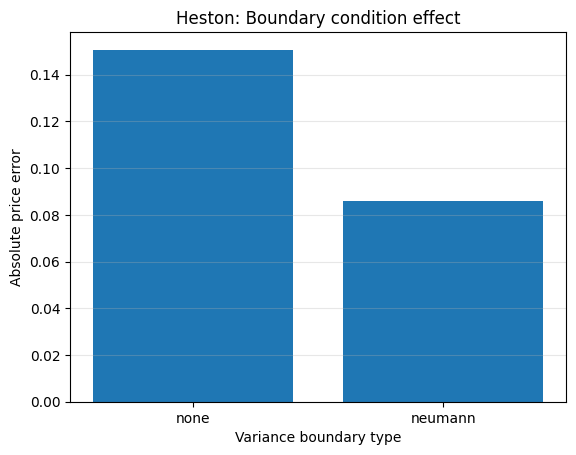

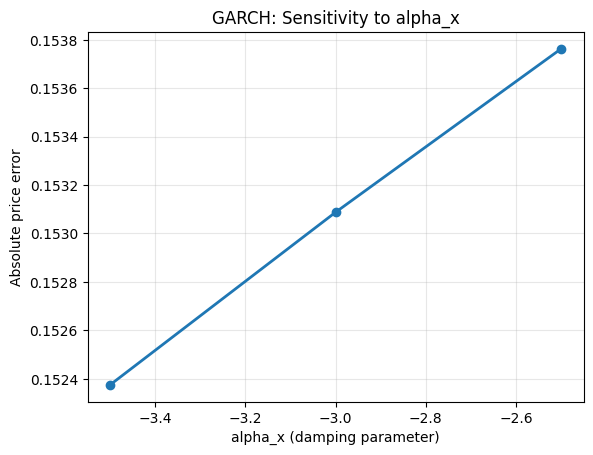

In [20]:
import matplotlib.pyplot as plt

# --- Lv sensitivity ---
plt.figure()
plt.plot(lv_df["Lv"], lv_df["abs_price_error"], marker="o", linewidth=2)
plt.title("Heston: Sensitivity to Lv")
plt.xlabel("Lv (variance domain size)")
plt.ylabel("Absolute price error")
plt.grid(True, alpha=0.3)
plt.show()


# --- Boundary condition sensitivity ---
plt.figure()
plt.bar(boundary_df["v_boundary"], boundary_df["abs_price_error"])
plt.title("Heston: Boundary condition effect")
plt.xlabel("Variance boundary type")
plt.ylabel("Absolute price error")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# --- Alpha sensitivity ---
plt.figure()
plt.plot(alpha_df["alpha_x"], alpha_df["abs_price_error"], marker="o", linewidth=2)
plt.title("GARCH: Sensitivity to alpha_x")
plt.xlabel("alpha_x (damping parameter)")
plt.ylabel("Absolute price error")
plt.grid(True, alpha=0.3)
plt.show()

**Reading the plots.**
- *Left ($L_v$ sensitivity):* U-shaped profile with minimum near $L_v \approx 0.30$. The left branch is dominated by truncation error $\sim e^{-\kappa L_v / \theta}$; the right branch by resolution loss $\sim (L_v/N_v)^2$. The theoretical optimum $L_v^* = (2\theta N_v^2/\kappa)^{1/3} \approx 0.29$ for these parameters matches the observed minimum.
- *Centre (Neumann effect):* the Neumann condition reduces the error by ≈ 1.7×, consistent with the $\mathcal{O}(\Delta v^2)$ improvement.
- *Right ($\alpha_x$ sensitivity):* error is nearly flat over the tested range, the damping is effective for any $\alpha_x \in [-3.5, -2.5]$, and the optimal value $\alpha_x = -3$ balances suppression of boundary artefacts against mild ill-conditioning of the $2\times 2$ shift system.

## Brief Observations

The results show that increasing the grid size improves pricing accuracy, as the absolute error decreases steadily with (N). This is consistent with convergence of the numerical scheme.

The truncation parameter (L) also affects accuracy: values that are too small introduce truncation error, while overly large values can reduce efficiency without improving results. An intermediate choice provides the best balance.

---

# Appendix A — Mathematical Framework

## A.1 BSDEs and the Markovian Representation

A **backward stochastic differential equation** (BSDE) couples a forward SDE for the state $X_t$ with a backward equation for the value process $(Y_t, Z_t)$:

$$Y_t = g(X_T) + \int_t^T f(s, X_s, Y_s, Z_s)\,ds - \int_t^T Z_s^\top dW_s$$

Here $Y_t$ is the option price, $Z_t$ is the hedging control (related to the Greeks), $g$ is the terminal payoff, and $f$ is the driver ($f = -rY$ for risk-neutral pricing). Under regularity assumptions (nonlinear Feynman–Kac), there exists a deterministic function $u$ such that $Y_t = u(t, X_t)$ and $Z_t = \sigma^\top \nabla u(t, X_t)$, reducing the problem to approximating $u$ on a spatial grid.

On a uniform time grid with step $\Delta t$, the backward recursion is:
$$\hat Y_k(x) = \mathbb{E}[Y_{k+1}(X_{t_{k+1}})\mid X_{t_k}=x], \qquad Y_k = \hat Y_k + \Delta t\,f(\cdot,\hat Y_k, \hat Z_k)$$

## A.2 The 1D Boundary-Controlled BSDE-CFFT Method

**Short-time Gaussian approximation.** By Euler–Maruyama, $\Delta X_k \approx \eta_k\Delta t + \sigma_k\sqrt{\Delta t}\,\xi$ with $\xi\sim\mathcal{N}(0,1)$, so the conditional expectation becomes a convolution evaluated via FFT in $\mathcal{O}(N\log N)$:
$$\widehat{\hat Y}_k(v) = \widehat{Y}_{k+1}(v) \cdot \psi_k(v), \qquad \psi_k(v) = e^{\Delta t(i\eta_k v - \sigma_k^2 v^2/2)}$$

**Boundary error and the damping-and-shifting fix.** The FFT implicitly periodises the function; the non-periodic call payoff causes severe oscillations. Gao–Hyndman (2025) subtract a shift $Ae^x + B$ (chosen to enforce boundary matching via a $2\times2$ system) and apply exponential damping $e^{\alpha x}$ with $\alpha < 0$, making the transformed function approximately periodic. The convolution multipliers are evaluated at the complex-shifted frequency $v+\alpha i$.

**Error bound (Gao–Hyndman):**
$$\text{err} \leq C_1\Delta t^{1/2} + C_2\Delta t + C_3\Delta t\,\Delta x + C_4\Delta t\,e^{-K_0\Delta t/\Delta x^2}$$
In the regime $\Delta x^2\sim\Delta t$ the dominant term is $\mathcal{O}(\Delta x^2)$, confirmed by the order-2 convergence in Part I.

## A.3 2D Local-Kernel Extension

**Why a single kernel fails.** The Heston/GARCH covariance $\Sigma(x,v)$ depends on $v$, breaking the translation invariance that makes a global 2D FFT exact. A single representative kernel would systematically misrepresent the dynamics at low and high variance.

**Local-kernel scheme.** For each variance slice $v_j$, build the Gaussian kernel with covariance $\Sigma(x,v_j)$. The backward update at $(x_i,v_j)$ uses the $j$-th kernel and retains only the $j$-th output row. The approximation error is $\mathcal{O}(\Delta v)$ per step (not $\mathcal{O}(1)$) because the kernel mismatch is bounded by $L_\Sigma|v_j - v_{j'}|\leq L_\Sigma\Delta v$.

**Diagonal IFFT strategy.** One global 2D FFT; then for each $j$, multiply by $\Psi^{(j)}$, partial IFFT along $v$, extract row $j$, IFFT along $x$. Equivalent to the full 2D convolution but avoids computing unused off-diagonal outputs, reducing complexity from $\mathcal{O}(N_v\cdot N_xN_v\log(N_xN_v))$ to $\mathcal{O}(N_xN_v(N_v\log N_v+\log N_x))$.

**Markovian controls.** By Feynman–Kac, $Z^{(1)} = \sigma_{x1}u_x + \sigma_{v1}u_v$ and $Z^{(2)} = \sigma_{x2}u_x + \sigma_{v2}u_v$, obtained simultaneously with the price by numerically differentiating the surface $u$ in a single post-loop pass.

---

# Appendix B — Computational Optimisations

Starting from a prototype runtime of ≈ 12 s on the largest grid ($N_x=160$, $N_v=80$, $n=1100$), six targeted optimisations reduced it to ≈ 2–2.5 s:

| # | Optimisation | Speedup (cumulative) | Principle |
|---|---|---|---|
| 1 | Multi-threaded `scipy.fft` | ×2 | 6-worker backend vs. single-threaded numpy |
| 2 | Precomputed static arrays | ×3 | Damping grids, phase factors, all $N_v$ local kernels built once at construction |
| 3 | Vectorised shift-solve | ×3.4 | $N_v$ independent $2\times2$ systems solved in one `numpy.linalg.solve` call |
| 4 | **Diagonal IFFT strategy** | ×4.6 | Most impactful — avoids $N_v-1$ wasted IFFT outputs per step |
| 5 | Conditional control computation | ×5 | Finite-difference $Z$ deferred to a single post-loop pass in European mode |
| 6 | In-place variance boundary control | ×5 | NumPy slice assignment eliminates extra memory allocation |

The diagonal IFFT (optimisation 4) is the key algorithmic contribution: it exploits the fact that for the $j$-th local kernel only the $j$-th output row is needed, cutting the dominant inner-loop cost by a factor proportional to $N_v$.

---

# Appendix C — Convergence Theory and Open Problems

## C.1 Four-term error decomposition (Theorem 6.1)

Under regularity assumptions (Lipschitz $\Sigma$, bounded transformed solution), the one-step error satisfies:

$$E^\ell \leq E^{\ell+1} + E_{\text{time}} + E_{\text{kernel}} + E_{\text{trunc}} + E_{\text{space}}$$

| Term | Order | Source |
|---|---|---|
| $E_{\text{time}}$ | $\mathcal{O}(\Delta t^{1/2})$ cumulated | Euler–Maruyama time discretisation |
| $E_{\text{kernel}}$ | $\mathcal{O}(L_\Sigma\,\Delta v\,\Delta t)$ | Local-kernel mismatch (new 2D term) |
| $E_{\text{trunc}}$ | $\mathcal{O}(e^{-K_0\Delta t/\Delta x^2} + e^{-\kappa L_v/\theta})$ | Domain truncation |
| $E_{\text{space}}$ | $\mathcal{O}(\Delta x^2 + \Delta v^2)$ | Spatial discretisation |

The $\mathcal{O}(\Delta v)$ (not $\mathcal{O}(1)$) bound on $E_{\text{kernel}}$ is the central theoretical insight: locality of the construction controls the mismatch by the grid spacing in $v$.

## C.2 $L^2$ stability (Theorem 6.2)

For the linear driver $f=-rY$, each local kernel is non-expansive ($|\Psi^{(j)}(\xi)|\leq 1$, characteristic function of a probability measure), so $\|\varepsilon^\ell\|_2 \leq (1+r\Delta t)\|\varepsilon^{\ell+1}\|_2 + \text{local error}$, with a global bound of $e^{rT}$ by Gronwall.

## C.3 Convergence conjecture and what remains open

Under joint refinement $\Delta x \sim \sqrt{\Delta t}$, $\Delta v \sim \sqrt{\Delta t}$, all four error terms are $\mathcal{O}(\Delta t^{1/2})$, suggesting a global rate of $\mathcal{O}(\Delta t^{1/2})$ (supported numerically but not yet proved). Two ingredients are missing:

**1. $\ell^\infty$ stability.** Theorem 6.2 is proved in $L^2$. Promoting it to $\ell^\infty$ for pointwise convergence at $(S_0, V_0)$ requires a discrete Sobolev embedding in 2D, introducing logarithmic factors.

**2. Inter-slice error coupling.** Adjacent slices interact through the global 2D FFT step. The coupling has not been bounded rigorously in $\ell^\infty$; a careful aliasing analysis for locally varying kernels is needed.

Closing these two gaps is the immediate agenda for a complete convergence theorem analogous to the 1D Gao–Hyndman result.

---